Current Working Directory:
c:\Users\sinde\Downloads\Indian_Developer_Burnout_Analysis

Visualizations folder path:
c:\Users\sinde\Downloads\Indian_Developer_Burnout_Analysis\Outputs\Visualizations

Processed Data folder path:
c:\Users\sinde\Downloads\Indian_Developer_Burnout_Analysis\Outputs\Processed_Data
Loaded: 5,000 rows × 50 columns
✔ Cleaned dataset saved
Clean dataset: 5,000 rows × 50 columns


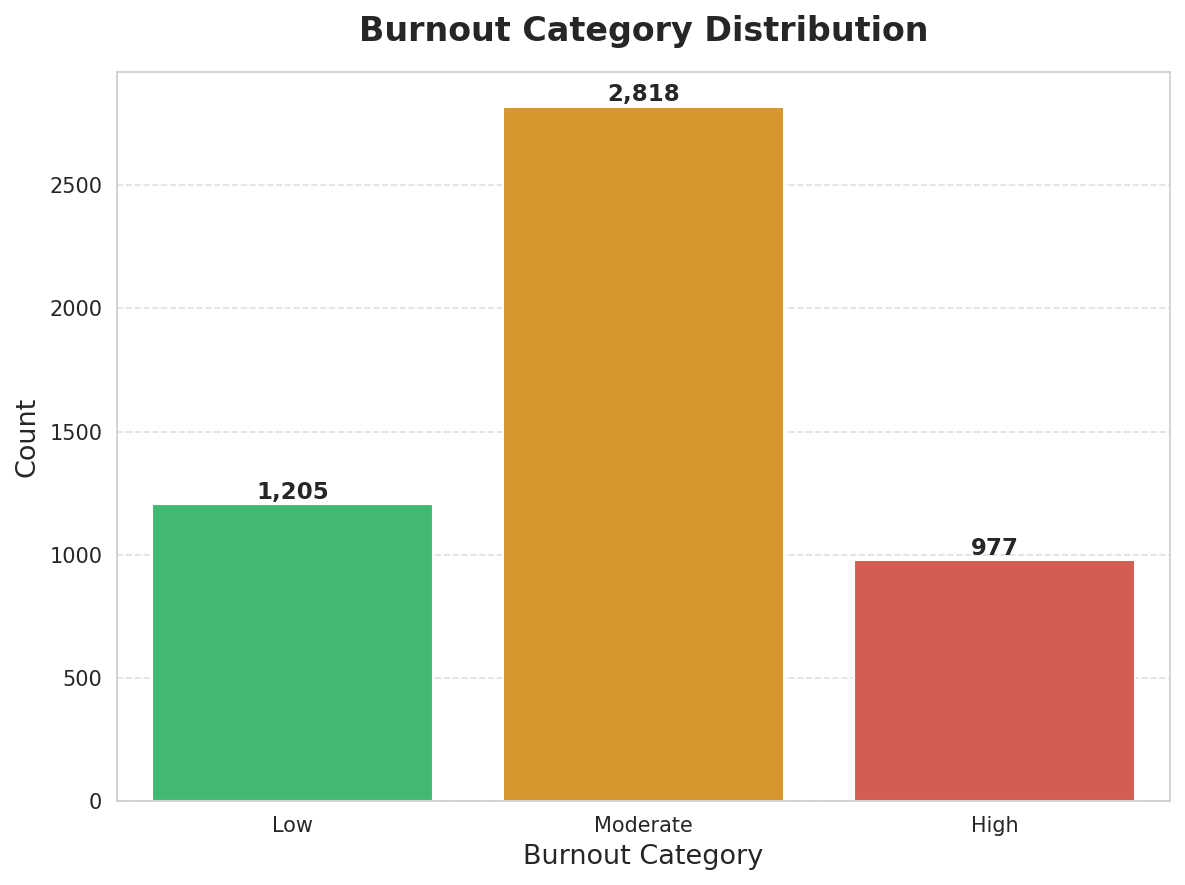

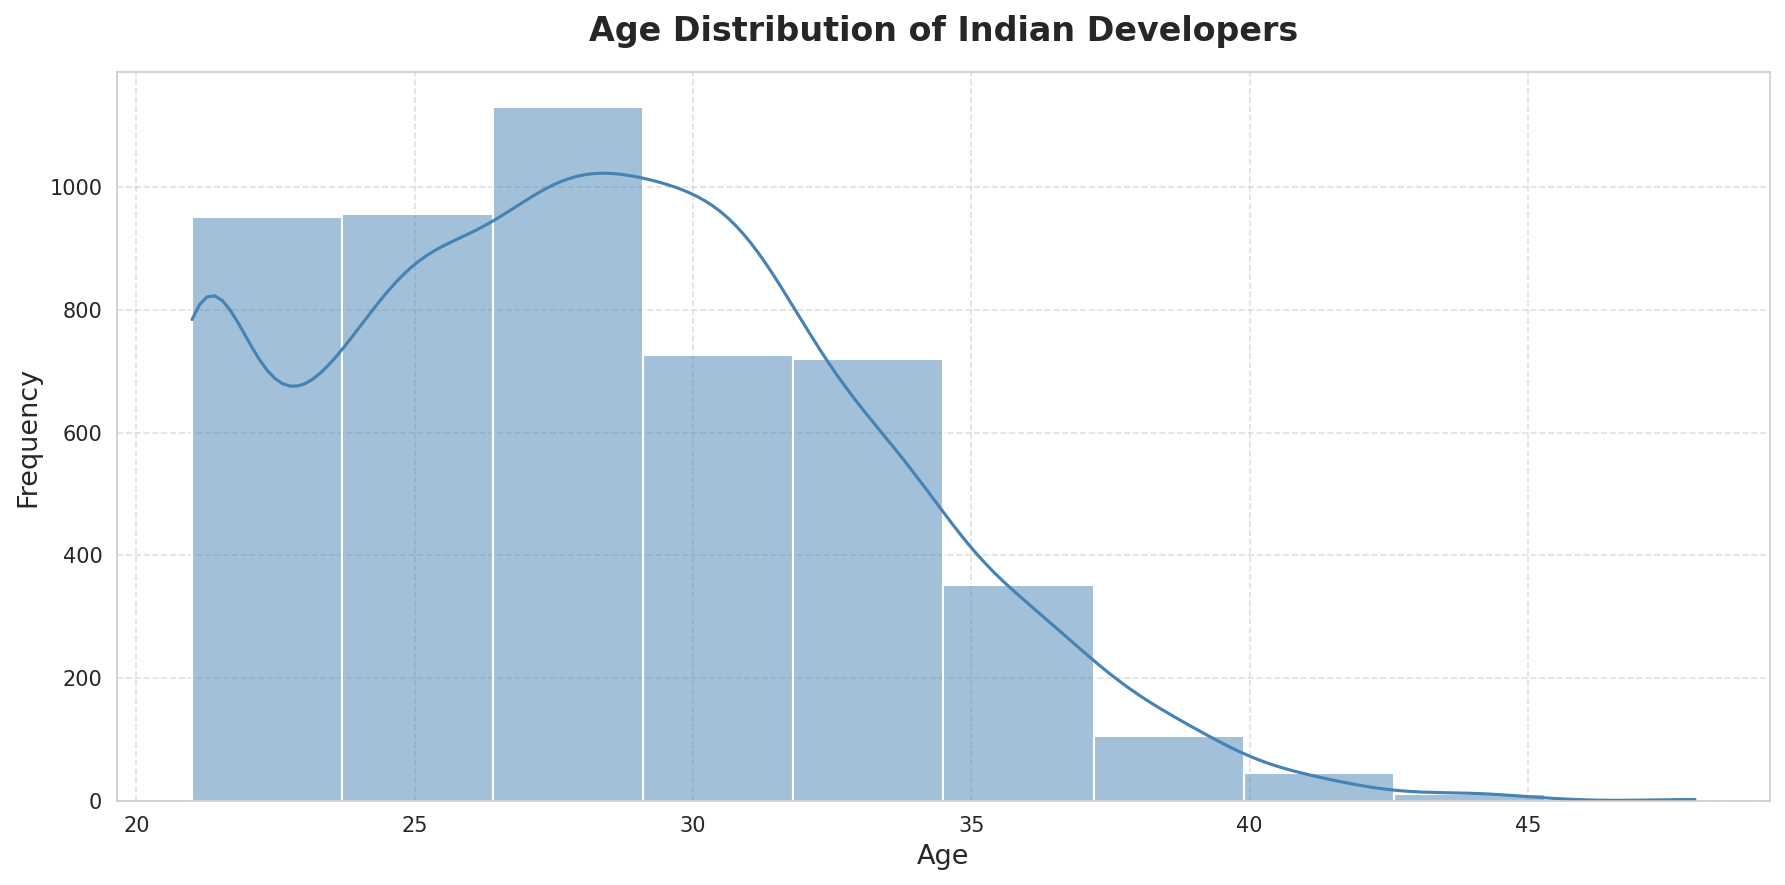

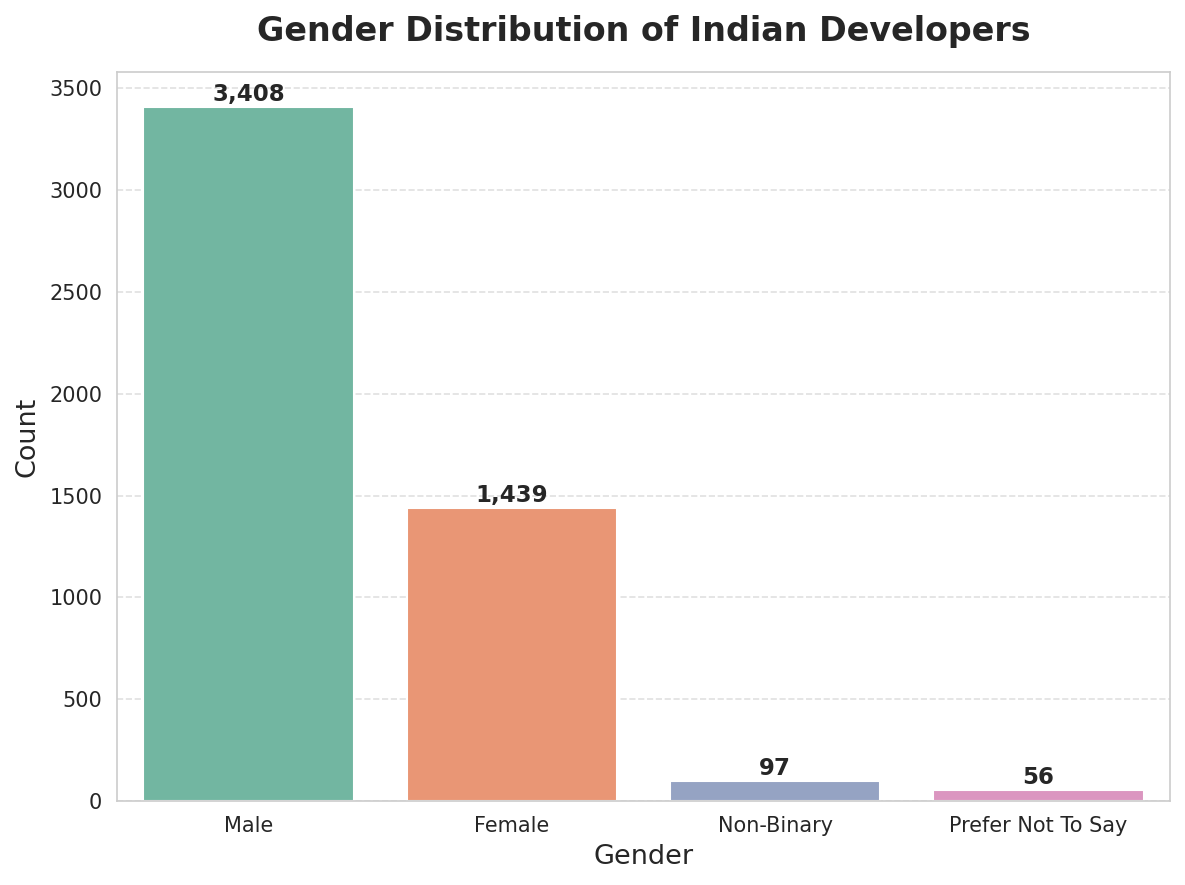


Total Developers : 5,000
Average Age      : 28.2 yrs  (Range: 21–48)
Dominant Gender  : Male  (68.2%)
Avg Burnout Score: 4.46 / 10
  High      : 19.5%
  Moderate  : 56.4%
  Low       : 24.1%

Avg Burnout Score by Gender:
gender
Female               4.47
Male                 4.47
Non-Binary           4.31
Prefer Not To Say    4.31

Charts saved in 'Outputs\Visualizations/'
Cleaned dataset saved in 'Outputs\Processed_Data/'


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Setup ──────────────────────────────────────────────
VISUALIZATION_DIR = os.path.join("Outputs", "Visualizations")
PROCESSED_DIR = os.path.join("Outputs", "Processed_Data")

os.makedirs(VISUALIZATION_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)
print("Current Working Directory:")
print(os.getcwd())

print("\nVisualizations folder path:")
print(os.path.abspath(VISUALIZATION_DIR))

print("\nProcessed Data folder path:")
print(os.path.abspath(PROCESSED_DIR))

sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 150, "font.family": "DejaVu Sans"})

# ── Load Data ──────────────────────────────────────────
df = pd.read_csv("indian_developer_burnout_2026.csv")
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

# ── Data Cleaning ──────────────────────────────────────
df.drop_duplicates(inplace=True)

str_cols = df.select_dtypes(include="object").columns
df[str_cols] = df[str_cols].apply(lambda c: c.str.strip().str.title())

critical = [c for c in ["age", "gender", "burnout_score"] if c in df.columns]
df.dropna(subset=critical, inplace=True)

if "age" in df.columns:
    df = df[df["age"].between(18, 65)]

if "burnout_score" in df.columns:
    df = df[df["burnout_score"].between(0, 10)]

df.to_csv(
    os.path.join(
        PROCESSED_DIR,
        "cleaned_burnout_data.csv"
    ),
    index=False
)

print("✔ Cleaned dataset saved")
print(f"Clean dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

# ── Burnout Category ───────────────────────────────────
def categorise_burnout(score):
    if score <= 3:   return "Low"
    elif score <= 6: return "Moderate"
    else:            return "High"

df["burnout_category"] = df["burnout_score"].apply(categorise_burnout)

cat_order  = ["Low", "Moderate", "High"]
cat_counts = (df["burnout_category"].value_counts()
                .reindex(cat_order).reset_index())
cat_counts.columns = ["burnout_category", "count"]

palette = {"Low": "#2ecc71", "Moderate": "#f39c12", "High": "#e74c3c"}

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=cat_counts, x="burnout_category", y="count",
            hue="burnout_category", palette=palette, legend=False, ax=ax)

for bar in ax.patches:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 3,
                f"{int(h):,}", ha="center", va="bottom",
                fontsize=11, fontweight="bold")

ax.set_title("Burnout Category Distribution", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Burnout Category", fontsize=13)
ax.set_ylabel("Count", fontsize=13)
ax.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(
    os.path.join(
        VISUALIZATION_DIR,
        "burnout_category.png"
    ),
    dpi=150,
    bbox_inches="tight"
)
plt.show()

# ── Age Distribution (Histogram) ───────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(df["age"].dropna(), bins=10, kde=True,
             color="steelblue", edgecolor="white", ax=ax)

ax.set_title("Age Distribution of Indian Developers", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Age", fontsize=13)
ax.set_ylabel("Frequency", fontsize=13)
ax.grid(linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(
    os.path.join(
        VISUALIZATION_DIR,
        "age_distribution.png"
    ),
    dpi=150,
    bbox_inches="tight"
)
plt.show()

# ── Gender Distribution (Bar Chart) ───────────────────
gender_counts = df["gender"].value_counts().reset_index()
gender_counts.columns = ["gender", "count"]

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=gender_counts, x="gender", y="count",
            hue="gender", palette="Set2", legend=False, ax=ax)

for bar in ax.patches:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 5,
                f"{int(h):,}", ha="center", va="bottom",
                fontsize=11, fontweight="bold")

ax.set_title("Gender Distribution of Indian Developers", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Gender", fontsize=13)
ax.set_ylabel("Count", fontsize=13)
ax.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(
    os.path.join(
        VISUALIZATION_DIR,
        "gender_distribution.png"
    ),
    dpi=150,
    bbox_inches="tight"
)
plt.show()

# ── Summary Insights ───────────────────────────────────
print(f"\nTotal Developers : {df.shape[0]:,}")
print(f"Average Age      : {df['age'].mean():.1f} yrs  (Range: {int(df['age'].min())}–{int(df['age'].max())})")

top_g     = df["gender"].value_counts()
top_g_pct = top_g.iloc[0] / top_g.sum() * 100
print(f"Dominant Gender  : {top_g.index[0]}  ({top_g_pct:.1f}%)")

print(f"Avg Burnout Score: {df['burnout_score'].mean():.2f} / 10")

for cat in ["High", "Moderate", "Low"]:
    pct = (df["burnout_category"] == cat).mean() * 100
    print(f"  {cat:<10}: {pct:.1f}%")

print("\nAvg Burnout Score by Gender:")
print(df.groupby("gender")["burnout_score"].mean().round(2).to_string())

print(
    f"\nCharts saved in "
    f"'{VISUALIZATION_DIR}/'"
)

print(
    f"Cleaned dataset saved in "
    f"'{PROCESSED_DIR}/'"
)